# ML-02 — Research Question and Provisional Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nane987/FlyRank-internship/blob/main/work/notebooks/w01_research_question.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Lane 2: Which visible pages under-capture clicks or engagement and deserve metadata, content, or monitoring review?


I chose this lane because it feels like a good balance between data analysis and machine learning, which is the direction I would like to explore further. In my previous experience, I have worked with data analysis and have also used ML, but mostly in different directions rather than this type of supervised learning approach. Therefore, I see this project as a valuable learning opportunity to develop my ML skills while still applying the data analysis techniques I am already familiar with. I am also interested in the practical aspect of the lane, since the goal is not only to build a model but also to turn the results into an actionable ranking and recommendations.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. The question: decision, action, cost of a wrong call

*What decision does your work improve? Who acts on it? What does a wrong recommendation cost?*

The work will improve the decision of which pages should be prioritized for content review and what type of action they may need, such as refreshing, expanding, protecting, pruning, or monitoring. This can be used by the content or SEO team to determine where to focus their time and resources first.

A wrong recommendation could have different costs depending on the action. Prioritizing a page that does not actually need attention could waste the team's time and resources, while failing to identify a page that is genuinely at risk could result in lost traffic, clicks, or engagement. Therefore, the goal is not to guarantee that a specific action will improve a page, but to provide a data-driven and interpretable prioritization that helps the team make better decisions about where to investigate first.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Quick look at the data (2-3 real numbers)

*Load the starter CSV below and show 2-3 real numbers that make your lane look worth the next 7 weeks.*

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")


Working dir: /content/flyrank-ml-internship-starter
Starter data found. You're ready.


In [3]:

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

In [12]:
df.columns

Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count',
       'char_count', 'provider_used', 'model_used', 'impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier',
       'age_tier_order', 'days_since_last_update', 'freshness_tier',
       'word_count_tier', 'char_count_tier', 'ctr', 'avg_position',
       'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier',
       'position_tier', 'trend_direction', 'trend_pct'],
      dtype='object')

In [9]:
df["trend_direction"].value_counts()

,count
trend_direction,
down,16262
stable,5962
up,4388
new,2236
flat,1152


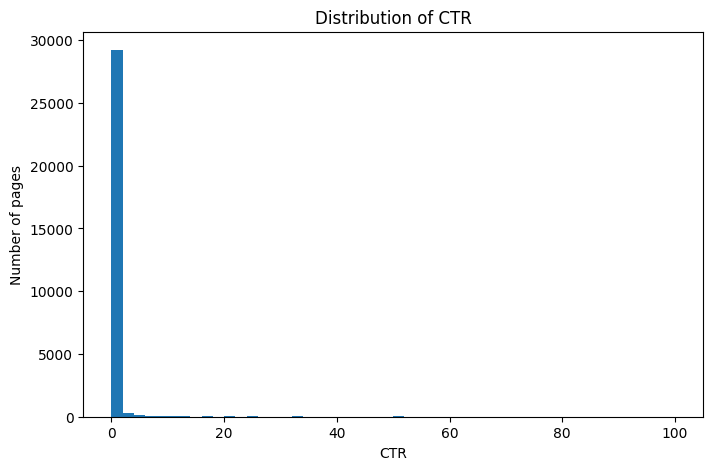

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["ctr"].dropna(), bins=50)

plt.xlabel("CTR")
plt.ylabel("Number of pages")
plt.title("Distribution of CTR")
plt.show()

This hostogram shows that there are huge nuber of pages that appear but do not get clicks (CTR 0 or near 0). This could be interesting to inverstigat and understand why

In [19]:
df["clicks_90d"].describe()

,clicks_90d
count,30000.000000
mean,16.097333
std,75.076958
min,0.000000
25%,0.000000
50%,1.000000
75%,7.000000
max,4178.000000


In [21]:
df["clicks_90d"].quantile([0.25, 0.5, 0.75, 0.9, 0.95])

,clicks_90d
0.25,0.00
0.50,1.00
0.75,7.00
0.90,32.00
0.95,69.05


In [8]:
# Correlation
df["avg_position"].corr(df["ctr"])

np.float64(-0.07259029976832464)

In [5]:
(df["avg_position"] <= 10).mean() * 100

np.float64(47.29333333333333)

In [6]:
df[df["avg_position"] <= 10]["ctr"].median()

0.11

In [7]:
df[df["avg_position"] > 10]["ctr"].median()

0.04

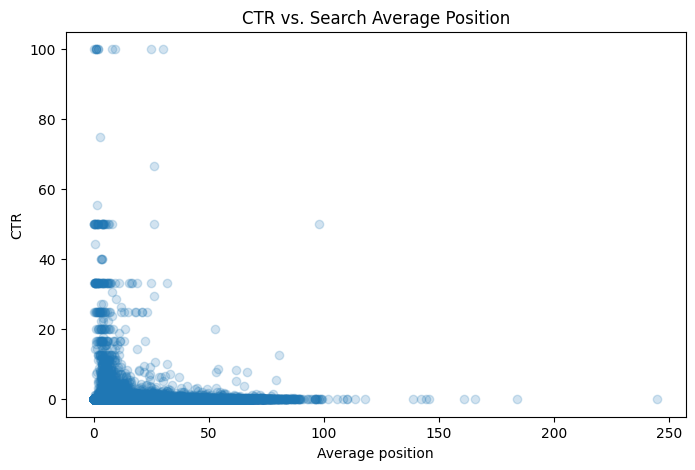

In [23]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["avg_position"],
    df["ctr"],
    alpha=0.2
)

plt.xlabel("Average position")
plt.ylabel("CTR")
plt.title("CTR vs. Search Average Position")

plt.show()

Search position appears strongly connected to user engagement: 47% of observations are in the top 10 positions, where median CTR is 0.11%, compared with 53% for lower-ranking observations. The correlation between position and CTR is -0.07. This suggests that improving search visibility could have a measurable impact.

## 4. Careful words: what I can and can't claim

*Write what your work will be able to say (observed, directional, decision-support) — and what it never will (causal proof, 'predicting Google').*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.